# <span style='color:Red'>Data preprocessing</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, os, pandas, seaborn, jlib
from matplotlib import pyplot

saveFigs = True
imagePath = 'img/bias/'
imageFormats = ['svg','pdf']
exportsPath = 'exports/'

minBiasValue = -10
maxBiasValue = 18

minBiasDistValue = -10
maxBiasDistValue = 10

minSlopeValue = -1
maxSlopeValue = 1

significanceSize = 14

nBinsHist = 45

paletteBase = {'Chunkable':'#a1c9f4','Non-chunkable':'#ffb482'}

if not os.path.exists(imagePath):
    os.makedirs(imagePath)

mapValueHandler = jlib.data.mapValueHandler.MapValueHandler(exportsPath+"exp3Values.csv")

allParticipantData = pandas.read_csv(exportsPath+'participantData_long_preEEG.csv')
allParticipantData.drop(['Mouse X path','Mouse Y path',],axis=1,inplace=True)

## <span style='color:Red'>Bias (random vs patterned)</span>

In [2]:
columnsToKeep = ['Subject','Trial type','Response error','Flipped error']

copyData = allParticipantData.copy()
copyData.drop([column for column in copyData.columns if column not in columnsToKeep],axis=1,inplace=True)

angleColumns = [column for column in copyData.columns if column not in ['Subject','Trial type','Cue type']]
meanData = copyData.groupby(['Subject','Trial type'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()
meanData

,Subject,Trial type,Response error,Flipped error
0,302,Chunkable,1.121358,1.947383
1,302,Non-chunkable,-3.106305,-4.288174
2,303,Chunkable,0.802182,4.008100
3,303,Non-chunkable,3.101176,-3.355693
4,305,Chunkable,0.446743,7.407754
5,305,Non-chunkable,-2.341830,1.810223
6,306,Chunkable,8.269336,3.447690
7,306,Non-chunkable,5.739044,-7.827508
8,307,Chunkable,-3.349647,7.395269
9,307,Non-chunkable,-1.431131,4.394825


## <span style='color:Red'>Bias (random vs patterned)</span>

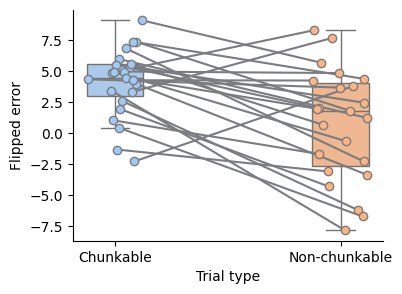

In [3]:
fig,ax = pyplot.subplots(figsize=(4,3))
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=meanData,
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteBase)
seaborn.despine()

In [4]:
meanNCTrialData = meanData[meanData['Trial type']=='Non-chunkable']['Flipped error'].to_numpy()
meanCTrialData = meanData[meanData['Trial type']=='Chunkable']['Flipped error'].to_numpy()

baseBiasTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       column1=meanCTrialData,column2=meanNCTrialData,
                                                       isStudent=True,isWilcoxon=False,hypothesis='different',
                                                       effectSize=True,descriptives=True)

baseBiasTtestPS['ttest'].columns = baseBiasTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSBiasAllTrialsChunkingEffect",
                            jlib.data.constants.extractTtestResults(baseBiasTtestPS['ttest'],0))

baseBiasTtestPS

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package 'jmv' was built under R version 4.4.3 



{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  3.765404  22.0  0.001067   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.785141  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.973343  0.768305,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   23  4.112506  4.483675  2.757151  0.574906
 "set21"  set2   23  0.737686  1.810223  4.521794  0.942859}

In [5]:
baseBiasTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[meanCTrialData,meanNCTrialData],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                       effectSize=True,descriptives=True)

baseBiasTtestOS['ttest'].columns = baseBiasTtestOS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestOSBiasAllTrialsChunkable",
                            jlib.data.constants.extractTtestResults(baseBiasTtestOS['ttest'],0,2))

mapValueHandler.setKeyValue("ttestOSBiasAllTrialsNonchunkable",
                            jlib.data.constants.extractTtestResults(baseBiasTtestOS['ttest'],1,2))

baseBiasTtestOS

{'ttest':          var         name       sta    df             p     esType         e
 "set0"  set0  Student's t  7.153357  22.0  1.794281e-07  Cohen's d  1.491578
 "set1"  set1  Student's t  0.782392  22.0  2.211623e-01  Cohen's d  0.163140,
 'normality':         name         w         p
 "set0"  set0  0.958222  0.428424
 "set1"  set1  0.967148  0.621105,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   23  4.112506  4.483675  2.757151  0.574906
 "set1"  set1   23  0.737686  1.810223  4.521794  0.942859}

### <span style='color:Red'>Only consider trials with abs(error) < 40</span>

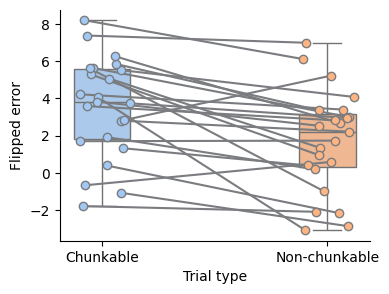

In [6]:
copyGoodData = copyData.copy()
copyGoodData = copyGoodData[numpy.abs(copyGoodData['Response error'])<=40]

meanGoodData = copyGoodData.groupby(['Subject','Trial type'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()

fig,ax = pyplot.subplots(figsize=(4,3))
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=meanGoodData,
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteBase)
seaborn.despine()

In [7]:
biasGoodNCTrialData = meanGoodData[meanGoodData['Trial type']=='Non-chunkable']['Flipped error'].to_numpy()
biasGoodCTrialData = meanGoodData[meanGoodData['Trial type']=='Chunkable']['Flipped error'].to_numpy()

goodBiasTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       column1=biasGoodCTrialData,
                                                       column2=biasGoodNCTrialData,
                                                       isStudent=True,isWilcoxon=False,hypothesis='different',
                                                       effectSize=True,descriptives=True)

goodBiasTtestPS['ttest'].columns = goodBiasTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSBiasGoodTrialsChunkingEffect",
                            jlib.data.constants.extractTtestResults(goodBiasTtestPS['ttest'],0))

goodBiasTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  4.005282  22.0  0.000595   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.835159  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.941193  0.190622,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   23  3.548034  3.824691  2.671818  0.557113
 "set21"  set2   23  1.708548  2.210537  2.725487  0.568303}

In [8]:
goodBiasTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[biasGoodCTrialData,biasGoodNCTrialData],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                       effectSize=True,descriptives=True)

goodBiasTtestOS['ttest'].columns = goodBiasTtestOS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestOSBiasGoodTrialsChunkable",
                            jlib.data.constants.extractTtestResults(goodBiasTtestOS['ttest'],0,2))

mapValueHandler.setKeyValue("ttestOSBiasGoodTrialsNonchunkable",
                            jlib.data.constants.extractTtestResults(goodBiasTtestOS['ttest'],1,2))

goodBiasTtestOS

{'ttest':          var         name       sta    df         p     esType         e
 "set0"  set0  Student's t  6.368611  22.0  0.000001  Cohen's d  1.327947
 "set1"  set1  Student's t  3.006402  22.0  0.003249  Cohen's d  0.626878,
 'normality':         name         w         p
 "set0"  set0  0.966623  0.608773
 "set1"  set1  0.968892  0.662505,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   23  3.548034  3.824691  2.671818  0.557113
 "set1"  set1   23  1.708548  2.210537  2.725487  0.568303}

## <span style='color:Red'>Bias = f(distance to mean)</span>

In [9]:
distCopyData = allParticipantData.copy()
nTargets = numpy.unique(distCopyData['Target']).shape[0]

distCopyData['Distance to mean'] = distCopyData.apply(
    lambda x: jlib.compression.experimentValues.splitByDistanceToMean(x,5,
                                                                      jlib.compression.constants.EXP3_OFFSET_ANGLE,
                                                                      nTargets,
                                                                      jlib.compression.constants.EXP3_RESPONSE_SECTIONS,
                                                                      expType='Exp3'),axis=1)

columnsToKeep = ['Subject','Trial type','Response error','Flipped error','Cue type','Distance to mean']
distCopyData.drop([column for column in distCopyData.columns if column not in columnsToKeep],axis=1,inplace=True)

angleColumns = [column for column in distCopyData.columns if column not in ['Subject','Trial type','Cue type','Distance to mean']]
distMeanData = distCopyData.groupby(['Subject','Trial type','Distance to mean'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()
distMeanData

,Subject,Trial type,Distance to mean,Response error,Flipped error
0,302,Chunkable,-16.0,-0.813226,-0.813226
1,302,Chunkable,-8.0,4.323361,4.323361
2,302,Chunkable,0.0,5.653785,5.171026
3,302,Chunkable,8.0,1.083205,-1.083205
4,302,Chunkable,16.0,-2.968966,2.968966
...,...,...,...,...,...
225,362,Non-chunkable,-16.0,0.460908,0.460908
226,362,Non-chunkable,-8.0,-3.612545,-3.612545
227,362,Non-chunkable,0.0,-6.555381,-0.637568
228,362,Non-chunkable,8.0,2.065759,-2.065759


C:\Users\juanm\AppData\Local\Temp\ipykernel_55904\1647458464.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['{a:.1f}'.format(a=float(tick.get_text())) for tick in ax.get_xticklabels()])


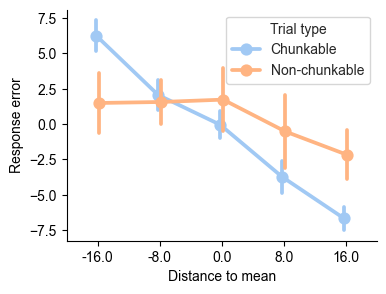

In [10]:
fig,ax = pyplot.subplots(figsize=(4,3))
seaborn.set_style('ticks')

seaborn.pointplot(ax=ax,
                  data=distMeanData,
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteBase)
ax.set_xticklabels(['{a:.1f}'.format(a=float(tick.get_text())) for tick in ax.get_xticklabels()])

seaborn.despine()

### <span style='color:Red'>Only consider trials with abs(error) < 40</span>

In [11]:
distGoodCopyData = distCopyData.copy()
distGoodCopyData = distGoodCopyData[numpy.abs(distGoodCopyData['Response error'])<=40]

angleColumns = [column for column in distGoodCopyData.columns if column not in ['Subject','Trial type','Cue type','Distance to mean']]
distGoodMeanData = distGoodCopyData.groupby(['Subject','Trial type','Distance to mean'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()
distGoodMeanData

,Subject,Trial type,Distance to mean,Response error,Flipped error
0,302,Chunkable,-16.0,-1.162016,-1.162016
1,302,Chunkable,-8.0,0.692932,0.692932
2,302,Chunkable,0.0,0.695063,0.793824
3,302,Chunkable,8.0,1.569021,-1.569021
4,302,Chunkable,16.0,-3.148125,3.148125
...,...,...,...,...,...
225,362,Non-chunkable,-16.0,5.854183,5.854183
226,362,Non-chunkable,-8.0,-1.390000,-1.390000
227,362,Non-chunkable,0.0,-4.301329,0.746028
228,362,Non-chunkable,8.0,-4.137462,4.137462


C:\Users\juanm\AppData\Local\Temp\ipykernel_55904\3098250153.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax.get_xticklabels()])


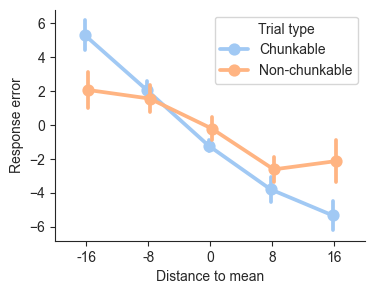

In [12]:
fig,ax = pyplot.subplots(figsize=(4,3))
seaborn.set_style('ticks')

seaborn.pointplot(ax=ax,
                  data=distGoodMeanData,
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteBase)
ax.set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax.get_xticklabels()])

seaborn.despine()

### <span style='color:Red'>Fit slopes and compare them</span>

In [13]:
columnsToKeep = ['Subject','Trial type','Response error','True target']

distGoodModelData = allParticipantData.copy()
distGoodModelData = distGoodModelData[numpy.abs(distGoodModelData['Response error'])<=40]
distGoodModelData['True target'] = (distGoodModelData['Continuous target']-distGoodModelData['Mean target'])/3
distGoodModelData.drop([column for column in distGoodModelData.columns if column not in columnsToKeep],axis=1,inplace=True)

allFitsC = []
allFitsNC = []

optimizationBounds = (numpy.array([-numpy.inf,-numpy.inf]),numpy.array([numpy.inf,numpy.inf]))

for participant in numpy.unique(distGoodModelData['Subject']):
    participantModelData = distGoodModelData[distGoodModelData['Subject']==participant]
    # print('Fitting data for participant',participant)
    # Fit chunkable trials
    xC = participantModelData[participantModelData['Trial type']=='Chunkable']['True target'].to_numpy()
    yC = participantModelData[participantModelData['Trial type']=='Chunkable']['Response error'].to_numpy()
    fitStartingPointC = [0,numpy.mean(yC)]
    fitC = jlib.analysis.models.fitLine(xC,yC,fitStartingPointC,optimizationBounds)
    allFitsC.append(fitC.x)
    # Fit non-chunkable trials
    xNC = participantModelData[participantModelData['Trial type']=='Non-chunkable']['True target'].to_numpy()
    yNC = participantModelData[participantModelData['Trial type']=='Non-chunkable']['Response error'].to_numpy()
    fitStartingPointNC = [0,numpy.mean(yNC)]
    fitNC = jlib.analysis.models.fitLine(xNC,yNC,fitStartingPointNC,optimizationBounds)
    allFitsNC.append(fitNC.x)

allFitsC = numpy.array(allFitsC)
allFitsNC = numpy.array(allFitsNC)

In [14]:
biasSlopesNCTrial = allFitsNC[:,0]
biasSlopesCTrial = allFitsC[:,0]

biasSlopeTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                        column1=biasSlopesNCTrial,column2=biasSlopesCTrial,
                                                        isStudent=True,isWilcoxon=False,hypothesis='different',
                                                        effectSize=True,descriptives=True)

biasSlopeTtestPS['ttest'].columns = biasSlopeTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSBiasSlopeGoodTrialsChunkingEffect",
                            jlib.data.constants.extractTtestResults(biasSlopeTtestPS['ttest'],0))

biasSlopeTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  4.837526  22.0  0.000078   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  1.008694  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.942401  0.202309,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   23 -0.137084 -0.166248  0.249854  0.052098
 "set21"  set2   23 -0.338868 -0.363242  0.259206  0.054048}

In [15]:
biasSlopeTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                        variables=[biasSlopesCTrial,biasSlopesNCTrial],
                                                        testValue=0,isStudent=True,isWilcoxon=False,hypothesis='lt',
                                                        effectSize=True,descriptives=True)

biasSlopeTtestOS['ttest'].columns = biasSlopeTtestOS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestOSBiasSlopeGoodTrialsChunkable",
                            jlib.data.constants.extractTtestResults(biasSlopeTtestOS['ttest'],0,2))

mapValueHandler.setKeyValue("ttestOSBiasSlopeGoodTrialsNonchunkable",
                            jlib.data.constants.extractTtestResults(biasSlopeTtestOS['ttest'],1,2))

biasSlopeTtestOS

{'ttest':          var         name       sta    df         p     esType         e
 "set0"  set0  Student's t -6.269728  22.0  0.000001  Cohen's d -1.307329
 "set1"  set1  Student's t -2.631270  22.0  0.007625  Cohen's d -0.548658,
 'normality':         name         w         p
 "set0"  set0  0.969975  0.688404
 "set1"  set1  0.980361  0.912231,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   23 -0.338868 -0.363242  0.259206  0.054048
 "set1"  set1   23 -0.137084 -0.166248  0.249854  0.052098}

In [16]:
mapValueHandler.saveData()

All data saved correctly to exports/exp3Values.csv


## <span style='color:Red'>Figures for publication</span>

### <span style='color:Red'>TBD</span>

C:\Users\juanm\AppData\Local\Temp\ipykernel_55904\3717617916.py:39: UserWarning: 
The palette list has fewer values (6) than needed (9) and will cycle, which may produce an uninterpretable plot.
  seaborn.lineplot(ax=ax['A'],data=distPlotData,x='Error to mean',y='Percent',hue='Distance to mean',legend=False,


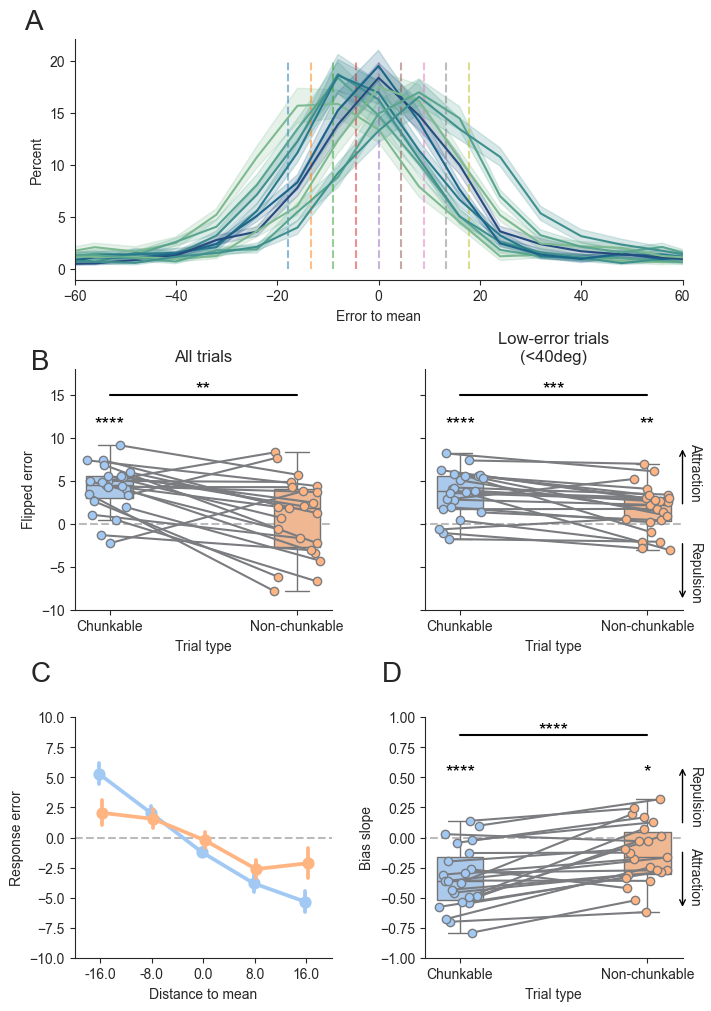

In [17]:
# Create the figure
fig,ax = pyplot.subplot_mosaic([['A','A'],['B','C'],['D','E']],figsize=(7,10),constrained_layout=True)
seaborn.set_style('ticks')

# Ax[0,0]: 
distFinalData = allParticipantData.copy()
distFinalData['Distance to mean'] = distFinalData.apply(
    lambda x: jlib.compression.experimentValues.splitByDistanceToMean(x,9,
                                                                      jlib.compression.constants.EXP3_OFFSET_ANGLE,
                                                                      nTargets,
                                                                      jlib.compression.constants.EXP3_RESPONSE_SECTIONS,
                                                                      expType='Exp3'),axis=1)

distFinalData['Response'] = distFinalData['Continuous target']*360/jlib.compression.constants.EXP3_RESPONSE_SECTIONS+distFinalData['Response error']
distPlotData = {'Subject':numpy.array([]),'Distance to mean':numpy.array([]),
                'Percent':numpy.array([]),'Error to mean':numpy.array([])}
i = 0
for dist in numpy.unique(distFinalData['Distance to mean']):
    dataDist = distFinalData.copy()
    dataDist.drop(dataDist[dataDist['Distance to mean']!=dist].index,inplace=True)
    dataDist['Error to mean'] = -dataDist['Mean target']*360/jlib.compression.constants.EXP3_RESPONSE_SECTIONS+dataDist['Response']
    dataDist['Error to mean'] = dataDist.apply(
        lambda x: numpy.arctan2(numpy.sin(x['Error to mean']*numpy.pi/180),
                                numpy.cos(x['Error to mean']*numpy.pi/180))*180/numpy.pi,axis=1)
    for participant in numpy.unique(dataDist['Subject']):
        participantData = dataDist.loc[(dataDist['Trial type']=='Chunkable') &
                                       (dataDist['Subject']==participant),'Error to mean'].copy()
        hist,binEdges = numpy.histogram(participantData,bins=45,range=(-180,180),
                                        weights=numpy.ones(participantData.shape[0],)*1/participantData.shape[0])
        binCenters = (binEdges[:-1]+binEdges[1:])/2
        distPlotData['Subject'] = numpy.concatenate((distPlotData['Subject'],numpy.ones(binCenters.shape[0],)*participant))
        distPlotData['Percent'] = numpy.concatenate((distPlotData['Percent'],hist*100))
        distPlotData['Error to mean'] = numpy.concatenate((distPlotData['Error to mean'],binCenters))
        distPlotData['Distance to mean'] = numpy.concatenate((distPlotData['Distance to mean'],
                                                              numpy.ones(binCenters.shape[0],)*dist))
    ax['A'].plot([dist,dist],[0,20],'--',alpha=0.5)#,color=seaborn.color_palette("crest")[i])
    i += 1
distPlotDF = pandas.DataFrame.from_dict(distPlotData)
seaborn.lineplot(ax=ax['A'],data=distPlotData,x='Error to mean',y='Percent',hue='Distance to mean',legend=False,
                 errorbar='se',palette=seaborn.color_palette("crest"))
ax['A'].set_xlim(-60,60)
ax['A'].text(-70,23,'A',fontsize=20)

# Ax[1,0]: bias for all trials
ax['B'].plot([-0.28,1.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPaired(ax=ax['B'],
                                     data=meanData,
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteBase)
ax['B'].set_xlim(-0.1875,1.1875)
ax['B'].set_ylim(minBiasValue,maxBiasValue)
ax['B'].text(-0.42,18,'B',fontsize=20)
ax['B'].set_title('All trials')
jlib.display.utils.displayPairwiseSignificance(ax['B'],[0,1],15*numpy.array([1,1]),size=significanceSize,
                                               p=baseBiasTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['B'],0,11,size=significanceSize,
                                               p=2*baseBiasTtestOS['ttest']['p'].to_numpy()[0])

# Ax[1,1]: bias for low-error trials
ax['C'].plot([-0.28,1.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPaired(ax=ax['C'],
                                     data=meanGoodData,
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteBase)
ax['C'].set_xlim(-0.1875,1.1875)
ax['C'].set_ylim(minBiasValue,maxBiasValue)
ax['C'].set_ylabel("")
ax['C'].set_yticklabels("")
ax['C'].set_title('Low-error trials\n(<40deg)')
jlib.display.utils.displayPairwiseSignificance(ax['C'],[0,1],15*numpy.array([1,1]),size=significanceSize,
                                               p=goodBiasTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['C'],0,11,size=significanceSize,
                                               p=2*goodBiasTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['C'],1,11,size=significanceSize,
                                               p=2*goodBiasTtestOS['ttest']['p'].to_numpy()[1])
ax['C'].annotate('',xy=(1,1/28),xytext=(1,8/28),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['C'].annotate('Repulsion',xy=(0,0),xytext=(1.02,1/28),textcoords='axes fraction',rotation=-90)
ax['C'].annotate('',xy=(1,19/28),xytext=(1,12/28),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['C'].annotate('Attraction',xy=(0,0),xytext=(1.02,13/28),textcoords='axes fraction',rotation=-90)

# Ax[2,0]: bias as a function of distance to mean
ax['D'].plot([-0.5,4.5],[0,0],'--',color='#bbbbbb')
seaborn.pointplot(ax=ax['D'],
                  data=distGoodMeanData,
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,legend=False,estimator=numpy.nanmean,
                  palette=paletteBase)
ax['D'].set_xlim(-0.5,4.5)
ax['D'].set_ylim(minBiasDistValue,maxBiasDistValue)
ax['D'].text(-1.35,13,'C',fontsize=20)

# Ax[2,1]: bias slopes
a = numpy.unique(meanData['Subject'])
b = numpy.array(['Chunkable','Non-chunkable'])
slopeDF = pandas.DataFrame.from_dict({'Subject':numpy.tile(a,b.size),
                                      'Trial type':numpy.repeat(b, a.size),
                                      'Bias slope':numpy.concatenate((biasSlopesCTrial,biasSlopesNCTrial),axis=0)})
ax['E'].plot([-0.28,1.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPaired(ax=ax['E'],
                                     data=slopeDF,
                                     x='Trial type',y='Bias slope',
                                     width=0.25,palette=paletteBase)
ax['E'].set_xlim(-0.1875,1.1875)
ax['E'].set_ylim(minSlopeValue,maxSlopeValue)
ax['E'].text(-0.42,1.3,'D',fontsize=20)
jlib.display.utils.displayPairwiseSignificance(ax['E'],[0,1],0.85*numpy.array([1,1]),size=significanceSize,
                                               p=biasSlopeTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],0,0.5,size=significanceSize,
                                               p=2*biasSlopeTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],1,0.5,size=significanceSize,
                                               p=2*biasSlopeTtestOS['ttest']['p'].to_numpy()[1])
ax['E'].annotate('',xy=(1,0.2),xytext=(1,0.45),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['E'].annotate('Attraction',xy=(0,0),xytext=(1.02,0.23),textcoords='axes fraction',rotation=-90)
ax['E'].annotate('',xy=(1,0.8),xytext=(1,0.55),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['E'].annotate('Repulsion',xy=(0,0),xytext=(1.02,0.55),textcoords='axes fraction',rotation=-90)

seaborn.despine()

if (saveFigs):
    for format in imageFormats:
        fig.savefig(imagePath+'biasAndChunking.'+format,format=format,dpi=1200)